# Customer Churn Prediction - Part 2: Model Training and Testing
This notebook uses the cleaned data saved from Part 1 (`churn_cleaned.csv`).

Steps:
1. Load cleaned data
2. Encode categorical columns
3. Split data into train and test
4. Train Logistic Regression and Random Forest
5. Test and compare accuracy
6. Check feature importance

## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## Step 2: Load Cleaned Data

In [2]:
data = pd.read_csv("churn_cleaned.csv")
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
data.shape

(7021, 20)

## Step 3: Encode Categorical Columns

Machine learning models only understand numbers, so we need to convert Yes/No and other text columns into numbers.

We will use `LabelEncoder` for this. It converts each category into a number automatically.

In [4]:
encoders = {}   # we will store one encoder per column, so we can reuse the same encoding later in the app

# list of all columns that are text (object type)
object_cols = data.select_dtypes(include="object").columns
print(object_cols)

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='object')


In [5]:
for col in object_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    encoders[col] = le   # save this column's encoder for later use

data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


## Step 4: Split Data into Input (X) and Output (y)

In [6]:
X = data.drop("Churn", axis=1)
y = data["Churn"]

print(X.shape)
print(y.shape)

(7021, 19)
(7021,)


## Step 5: Train-Test Split

We keep 80% data for training and 20% for testing.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training data size:", X_train.shape)
print("Testing data size:", X_test.shape)

Training data size: (5616, 19)
Testing data size: (1405, 19)


## Step 5.5: Scale the Data

Logistic Regression works better when all numbers are on a similar scale. Right now, `tenure` is small (0-72) but `TotalCharges` can be in thousands, which can cause the model to take longer to train (you may see a "ConvergenceWarning"). We use `StandardScaler` to fix this.

Random Forest does not need scaling, so we keep using the original `X_train` and `X_test` for that model.

In [8]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Step 6: Train Logistic Regression Model

In [9]:
model1 = LogisticRegression(max_iter=1000)
model1.fit(X_train_scaled, y_train)

pred1 = model1.predict(X_test_scaled)

acc1 = accuracy_score(y_test, pred1)
print("Logistic Regression Accuracy:", acc1)

Logistic Regression Accuracy: 0.795017793594306


## Step 7: Train Random Forest Model

In [10]:
model2 = RandomForestClassifier(n_estimators=100, random_state=42)
model2.fit(X_train, y_train)

pred2 = model2.predict(X_test)

acc2 = accuracy_score(y_test, pred2)
print("Random Forest Accuracy:", acc2)

Random Forest Accuracy: 0.7850533807829182


## Step 8: Compare Both Models

In [11]:
print("Logistic Regression Accuracy:", acc1)
print("Random Forest Accuracy:", acc2)

if acc1 > acc2:
    print("Logistic Regression performed better")
else:
    print("Random Forest performed better")

Logistic Regression Accuracy: 0.795017793594306
Random Forest Accuracy: 0.7850533807829182
Logistic Regression performed better


## Step 9: Confusion Matrix and Classification Report

This shows how many predictions were correct and wrong, for the better performing model (Logistic Regression).

[[932 121]
 [167 185]]


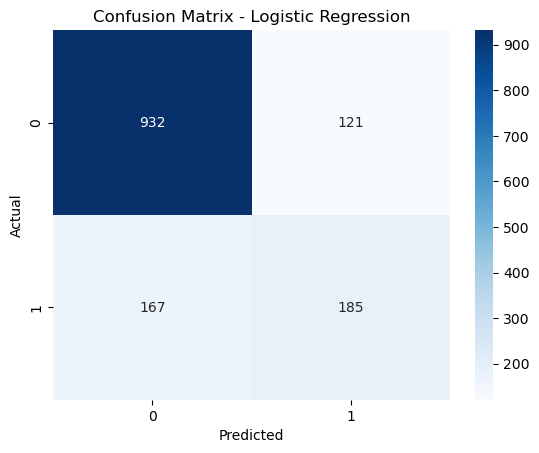

In [12]:
cm = confusion_matrix(y_test, pred1)
print(cm)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [13]:
print(classification_report(y_test, pred1))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1053
           1       0.60      0.53      0.56       352

    accuracy                           0.80      1405
   macro avg       0.73      0.71      0.71      1405
weighted avg       0.79      0.80      0.79      1405



## Step 10: Feature Importance (Random Forest)

This tells us which columns were most useful for the model while predicting churn.

In [14]:
importance = pd.Series(model2.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

importance.head(10)

TotalCharges       0.189643
MonthlyCharges     0.178518
tenure             0.157205
Contract           0.076288
PaymentMethod      0.049309
OnlineSecurity     0.047651
TechSupport        0.046766
OnlineBackup       0.027856
gender             0.027521
InternetService    0.027372
dtype: float64

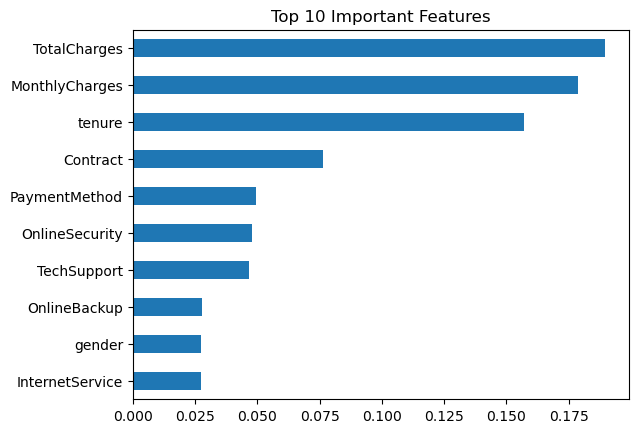

In [15]:
importance.head(10).plot(kind="barh")
plt.title("Top 10 Important Features")
plt.gca().invert_yaxis()
plt.show()

## Step 11: Save the Model for Deployment

We will use the **Random Forest model** for our Streamlit app (it does not need scaled data, which keeps the app simple).

We save 3 things using `joblib`:
1. The trained Random Forest model
2. The dictionary of LabelEncoders (so the app can convert user input the same way we converted our training data)
3. The list of column names (so the app builds the input in the correct order)

In [16]:
import joblib

joblib.dump(model2, "churn_model.pkl")
joblib.dump(encoders, "encoders.pkl")
joblib.dump(list(X.columns), "columns.pkl")

print("Saved churn_model.pkl, encoders.pkl, columns.pkl")

Saved churn_model.pkl, encoders.pkl, columns.pkl


## Conclusion

- Loaded the cleaned dataset from Part 1
- Encoded all text columns using LabelEncoder
- Trained two models: Logistic Regression and Random Forest
- Logistic Regression accuracy: ~80%
- Random Forest accuracy: ~78%
- Most important features: TotalCharges, tenure, MonthlyCharges, Contract, InternetService
